<center>
    <h2>Apurba Koirala</h2>
    <h3>22BCE3799</h3>
    <h3>Guided by: Dr. Sharmila C</h3>
    <h4> Deep Learning Lab Assessment-1</h4>
    <h4> Lab Slot L9+ L10
</center>

## Question no 1
You have recently joined a company as a machine learning intern. Your task is todevelopasimple binary emotion classifier using EEG signals recorded from two electrodes, representingFeature 1 and Feature 2. The company provides labeled training data fromtwo emotional states:
* Relaxed: [2, 3], [1, 4], [2, 4]
* Stressed: [4, 2], [5, 1], [4, 3]

The emotional states are labeled as follows:
* Relaxed → Class = +1
* Stressed → Class = –1

Write a Python program to:
* Implement the perceptron learning algorithm with step-by-step weight updates.
* Visualize the errors across epochs.
* Demonstrate convergence of weights when applied to a linearly separable dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
X = [
    [2, 3],  # Relaxed
    [1, 4],  # Relaxed
    [2, 4],  # Relaxed
    [4, 2],  # Stressed
    [5, 1],  # Stressed
    [4, 3],  # Stressed
]


In [3]:
y = [1, 1, 1, -1, -1, -1]

In [4]:
X_pos = [X[i] for i in range(len(X)) if y[i] == 1]   # Relaxed
X_neg = [X[i] for i in range(len(X)) if y[i] == -1]  # Stressed

In [5]:
x1_pos = [pt[0] for pt in X_pos]
x2_pos = [pt[1] for pt in X_pos]
x1_neg = [pt[0] for pt in X_neg]
x2_neg = [pt[1] for pt in X_neg]

In [6]:
x1_pos

[2, 1, 2]

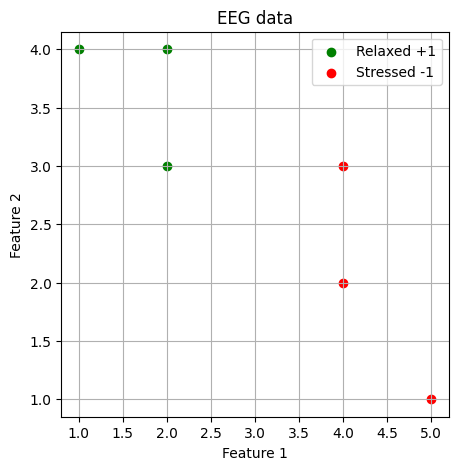

In [7]:
plt.figure(figsize = (5,5))
plt.scatter(x1_pos, x2_pos, color = 'green', label = "Relaxed +1")
plt.scatter(x1_neg, x2_neg, color = 'red', label = "Stressed -1")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.title("EEG data")
plt.show()

In [8]:
def predict (x, w, b):
  result = w[0] * x[0] + w[1] * x[1] + b
  if result >= 0:
    return 1
  else:
    return -1

In [9]:
w = [0, 0]  # weights
b = 0       # bias
eta = 1     # learning rate
max_epochs = 100
errors_per_epoch = []

In [10]:
for epoch in range(max_epochs):
    errors = 0
    for i in range(len(X)):
        y_pred = predict(X[i], w, b)
        if y_pred != y[i]:
            # Update weights and bias
            w[0] += eta * y[i] * X[i][0]
            w[1] += eta * y[i] * X[i][1]
            b += eta * y[i]
            errors += 1
    errors_per_epoch.append(errors)

    # Early stopping if converged
    if errors == 0:
        print(f"Converged after {epoch+1} epochs. Final weights {w} and final bias {b}")
        break

Converged after 7 epochs. Final weights [-6, 6] and final bias 1


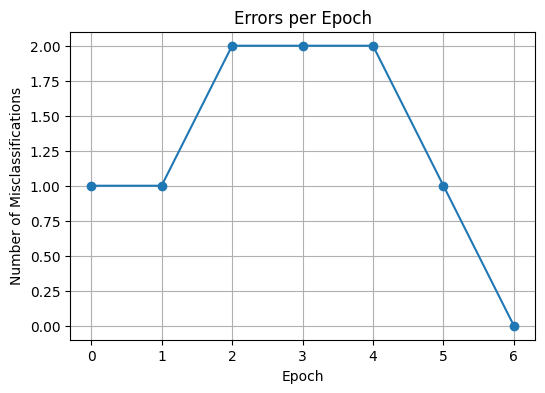

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(errors_per_epoch, marker='o')
plt.title("Errors per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.grid(True)
plt.show()

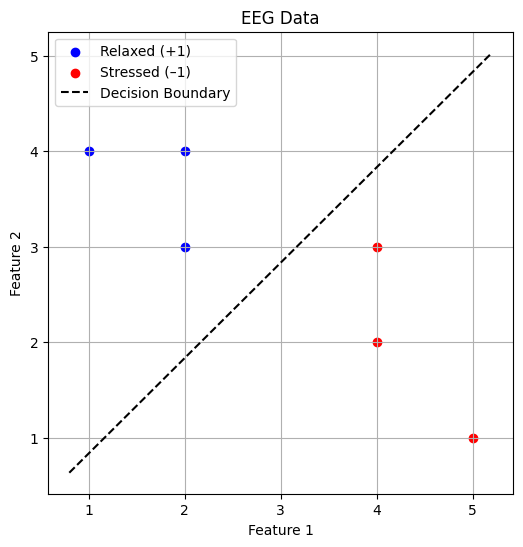

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(x1_pos, x2_pos, color='blue', label='Relaxed (+1)')
plt.scatter(x1_neg, x2_neg, color='red', label='Stressed (–1)')


x_vals = np.array(plt.gca().get_xlim())  # get current x-axis limits
y_vals = -(w[0]/w[1]) * x_vals - b/w[1]  # compute y from the boundary equation

plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('EEG Data')
plt.legend()
plt.grid(True)
plt.show()

## Question 2
You are working with a healthcare startup building an AI-powered assistant that helpsdoctors identify whether a patient is likely experiencing flu symptoms or allergic reactions—two conditions that often overlap in early presentations. The sensor inputs includebodytemperature and nasal inflammation readings from smart diagnostic patches. Unfortunately, the data distribution is linearly inseparable due to physiological variabilityamong patients (e.g. some allergic patients also have high temperatures). To increase diagnostic accuracy, your task is to build a Multilayer FeedforwardNeuralNetwork that learns complex boundaries and confidently distinguishes betweenthetwoclasses.
Demonstrate how an MLFFNN can correctly classify non-linearly separable patterns (FluvsAllergy) using symptom intensity as features in a binary class setup with gradient descent
weight updation policy.
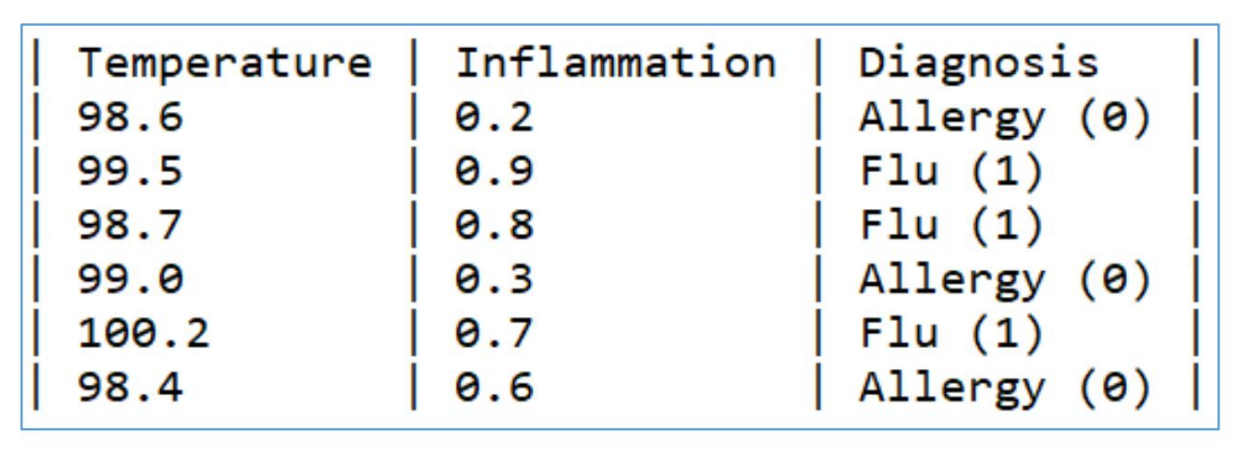

Lab Tasks

Build an MLFFNN with:
* 2 input neurons (features)
* One hidden layer (with 3–5 neurons using ReLU or tanh)
* Output layer with a sigmoid neuron
* Train using backpropagation and binary cross-entropy loss
* Track convergence metrics, prediction accuracy, and visualize the feature transformation.

In [13]:
X = np.array([[98.6, 0.2], [99.5, 0.9], [98.7, 0.8], [99.0, 0.3], [100.2, 0.7], [98.4, 0.6]])

In [14]:
y = np.array([0, 1, 1, 0, 1, 0])

In [15]:
X_flu = X[y==1]
X_allergy = X[y==0]

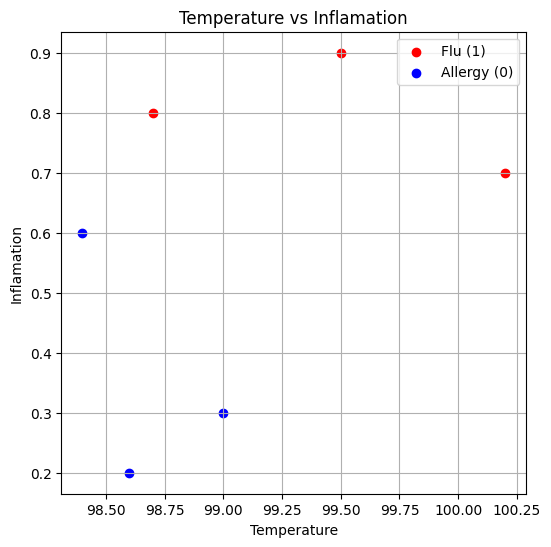

In [16]:
plt.figure(figsize=(6, 6))

plt.scatter(X_flu[:, 0], X_flu[:, 1], color='red', label='Flu (1)')
plt.scatter(X_allergy[:, 0], X_allergy[:, 1], color='blue', label='Allergy (0)')

plt.xlabel('Temperature')
plt.ylabel('Inflamation')

plt.grid(True)
plt.legend()
plt.title('Temperature vs Inflamation')
plt.show()

In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [18]:
X_scaled = StandardScaler().fit_transform(X)

In [19]:
X_scaled

array([[-0.75814251, -1.5067801 ],
       [ 0.70398947,  1.24473139],
       [-0.5956834 ,  0.85165832],
       [-0.10830607, -1.11370703],
       [ 1.84120323,  0.45858525],
       [-1.08306072,  0.06551218]])

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

In [21]:
model = models.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(5, activation = 'relu'),
    layers.Dense(1, activation = 'sigmoid')
])

In [22]:
model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [23]:
history = model.fit(X_scaled, y, epochs = 100, verbose = 1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6667 - loss: 0.6159
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6667 - loss: 0.6145
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6667 - loss: 0.6131
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6667 - loss: 0.6117
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6667 - loss: 0.6104
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6667 - loss: 0.6090
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6667 - loss: 0.6076
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6667 - loss: 0.6062
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6667 - loss: 0.6048
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6667 - loss: 0.6034
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6667 - loss: 0.6021
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6667 - loss

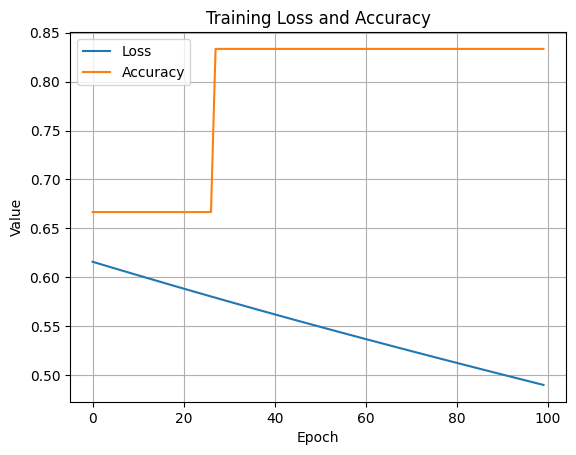

In [24]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Loss and Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
preds = model.predict(X_scaled)
print(preds)  #probabilities

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
[[0.17115422]
 [0.56246585]
 [0.5861282 ]
 [0.25742847]
 [0.4880488 ]
 [0.46275705]]


In [26]:
pred_classes = (preds >= 0.5).astype(int)
print(pred_classes)


[[0]
 [1]
 [1]
 [0]
 [0]
 [0]]


## Question 3

You’ll train a basic feedforward neural network to approximate the function:

y = 3x^2 + 2x + 1

This clean regression task allows you to clearly observe how optimizers impact convergence, learning rate adaptation, and final accuracy

Python snippet to generate the data

# Synthetic dataset
import numpy as np

X = np.linspace(-10, 10, 1000).reshape(-1, 1)

y = 3 * X**2 + 2 * X + 1 + np.random.normal(0, 10, X.shape)

Network Architecture
- Input: 1 feature
- Hidden layers: [16 → 8 neurons], ReLU activations
- Output: 1 neuron, linear activation
- Loss: Mean Squared Error (MSE)
Optimizers to Compare
Train identical models with: - SGD
- SGD + Momentum
- RMSprop
- Adam

Use your own values of Epochs,Batch size and Learning rate
Display the following with plots
- Loss vs Epoch plots for each optimizer
- Training time
- Final loss values
- Scatter plot of predicted vs true values

In [27]:
X = np.linspace(-10, 10, 1000).reshape(-1, 1)

y = 3 * X**2 + 2 * X + 1 + np.random.normal(0, 10, X.shape)

In [28]:
X.shape

(1000, 1)

In [29]:
y.shape

(1000, 1)

In [30]:
X

array([[-10.        ],
       [ -9.97997998],
       [ -9.95995996],
       [ -9.93993994],
       [ -9.91991992],
       [ -9.8998999 ],
       [ -9.87987988],
       [ -9.85985986],
       [ -9.83983984],
       [ -9.81981982],
       [ -9.7997998 ],
       [ -9.77977978],
       [ -9.75975976],
       [ -9.73973974],
       [ -9.71971972],
       [ -9.6996997 ],
       [ -9.67967968],
       [ -9.65965966],
       [ -9.63963964],
       [ -9.61961962],
       [ -9.5995996 ],
       [ -9.57957958],
       [ -9.55955956],
       [ -9.53953954],
       [ -9.51951952],
       [ -9.4994995 ],
       [ -9.47947948],
       [ -9.45945946],
       [ -9.43943944],
       [ -9.41941942],
       [ -9.3993994 ],
       [ -9.37937938],
       [ -9.35935936],
       [ -9.33933934],
       [ -9.31931932],
       [ -9.2992993 ],
       [ -9.27927928],
       [ -9.25925926],
       [ -9.23923924],
       [ -9.21921922],
       [ -9.1991992 ],
       [ -9.17917918],
       [ -9.15915916],
       [ -9

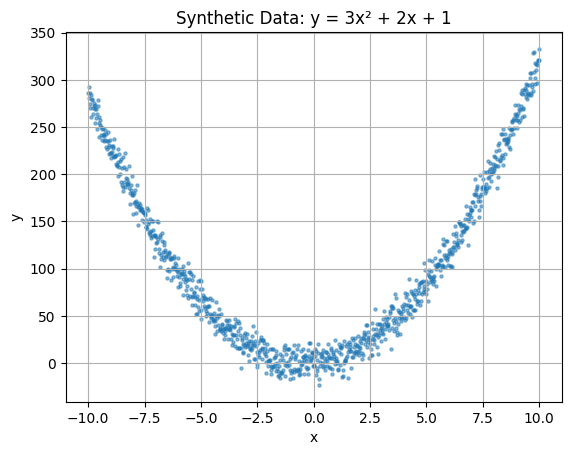

In [31]:
plt.scatter(X, y, s=5, alpha=0.5)
plt.title("Synthetic Data: y = 3x² + 2x + 1")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [32]:
X = MinMaxScaler(feature_range=(-1, 1)).fit_transform(X)
X

array([[-1.        ],
       [-0.997998  ],
       [-0.995996  ],
       [-0.99399399],
       [-0.99199199],
       [-0.98998999],
       [-0.98798799],
       [-0.98598599],
       [-0.98398398],
       [-0.98198198],
       [-0.97997998],
       [-0.97797798],
       [-0.97597598],
       [-0.97397397],
       [-0.97197197],
       [-0.96996997],
       [-0.96796797],
       [-0.96596597],
       [-0.96396396],
       [-0.96196196],
       [-0.95995996],
       [-0.95795796],
       [-0.95595596],
       [-0.95395395],
       [-0.95195195],
       [-0.94994995],
       [-0.94794795],
       [-0.94594595],
       [-0.94394394],
       [-0.94194194],
       [-0.93993994],
       [-0.93793794],
       [-0.93593594],
       [-0.93393393],
       [-0.93193193],
       [-0.92992993],
       [-0.92792793],
       [-0.92592593],
       [-0.92392392],
       [-0.92192192],
       [-0.91991992],
       [-0.91791792],
       [-0.91591592],
       [-0.91391391],
       [-0.91191191],
       [-0

In [33]:
import time

In [34]:
optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.1),
    'SGD+Momentum': tf.keras.optimizers.SGD(learning_rate=0.03, momentum=0.9),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.003),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}

In [35]:
def train_with_optimizer(name, optimizer):
    model = models.Sequential([
        layers.Input(shape = (1,)),
        layers.Dense(16, activation = 'relu'),
        layers.Dense(8, activation = 'relu'),
        layers.Dense(1, activation = 'linear')
    ])

    model.compile(optimizer=optimizer, loss='mse')

    start = time.time()
    history = model.fit(X, y, epochs=100, batch_size=32, verbose=0)
    duration = time.time() - start

    final_loss = history.history['loss'][-1]

    print(f"{name} — Final Loss: {final_loss:.4f}, Time: {duration:.2f}s")

    return history.history['loss'], final_loss, duration, model


In [36]:
loss_histories = {}
final_losses = {}
train_times = {}
trained_models = {}

for name, opt in optimizers.items():
    print(f"Training with {name}...")
    loss, final_loss, duration, model = train_with_optimizer(name, opt)

    loss_histories[name] = loss
    final_losses[name] = final_loss
    train_times[name] = duration
    trained_models[name] = model

Training with SGD...
SGD — Final Loss: 8347.5322, Time: 14.74s
Training with SGD+Momentum...
SGD+Momentum — Final Loss: 8332.3301, Time: 12.22s
Training with RMSprop...
RMSprop — Final Loss: 103.2163, Time: 12.78s
Training with Adam...
Adam — Final Loss: 6433.3408, Time: 13.39s


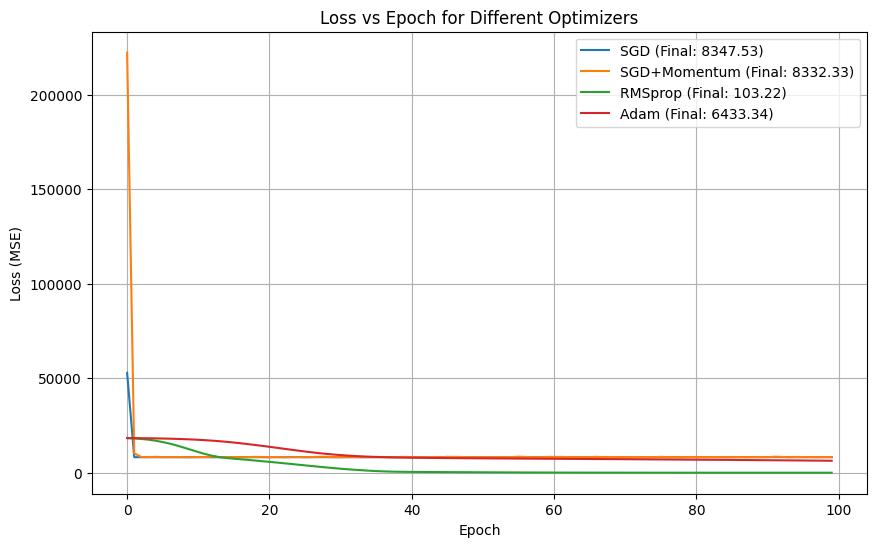

In [37]:

plt.figure(figsize=(10, 6))

for name, loss in loss_histories.items():
    plt.plot(loss, label=f"{name} (Final: {final_losses[name]:.2f})")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epoch for Different Optimizers")
plt.legend()
plt.grid(True)
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


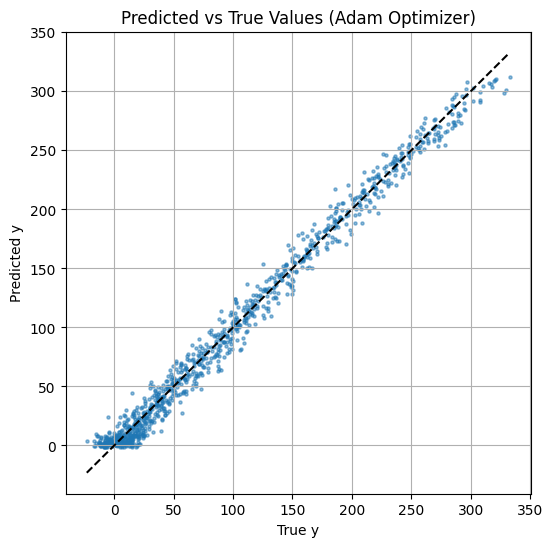

In [38]:
y_pred = trained_models['RMSprop'].predict(X)

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.5, s=5)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Predicted vs True Values (Adam Optimizer)")
plt.grid(True)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')  # y = x line
plt.show()

## Question 4
You're working with a financial tech company building an automated check-processingsystem. One key task is to read handwritten numeric account codes fromscannedchecks. Thesystem must be both highly accurate and computationally efficient.

To validate different neural network strategies, you're required to implement adigitclassification system using the MNIST dataset (digits 0–9, 10 classes) using two approaches:
- A deep learning framework (e.g., PyTorch, TensorFlow) and use CrossEntropyLossandAdam optimizer
- Manual implementation using NumPy without any deep learning framework
Train a simple feedforward ANN on the MNIST dataset (10 classes) using both approachesand compare their behavior.

In [39]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [40]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [41]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [42]:
X_train.shape

(60000, 28, 28)

In [43]:
y_train.shape

(60000,)

In [44]:
X_train = X_train.reshape(-1, 28*28).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28*28).astype("float32") / 255.0

In [45]:
X_train.shape

(60000, 784)

In [46]:
28*28

784

In [47]:
model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [48]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data = (X_test, y_test))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8508 - loss: 0.5039 - val_accuracy: 0.9593 - val_loss: 0.1390
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9628 - loss: 0.1232 - val_accuracy: 0.9654 - val_loss: 0.1086
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9750 - loss: 0.0796 - val_accuracy: 0.9750 - val_loss: 0.0854
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9841 - loss: 0.0546 - val_accuracy: 0.9769 - val_loss: 0.0744
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9861 - loss: 0.0443 - val_accuracy: 0.9754 - val_loss: 0.0813
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9896 - loss: 0.0338 - val_accuracy: 0.9794 - val_loss: 0.0814
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9911 - loss: 0.0271 - val_accuracy: 0.9765 - val_loss: 0.0839
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9917 - loss: 0.0260 - val_accuracy: 0.

In [50]:
test_acc = model.evaluate(X_test, y_test, verbose=0)[1]

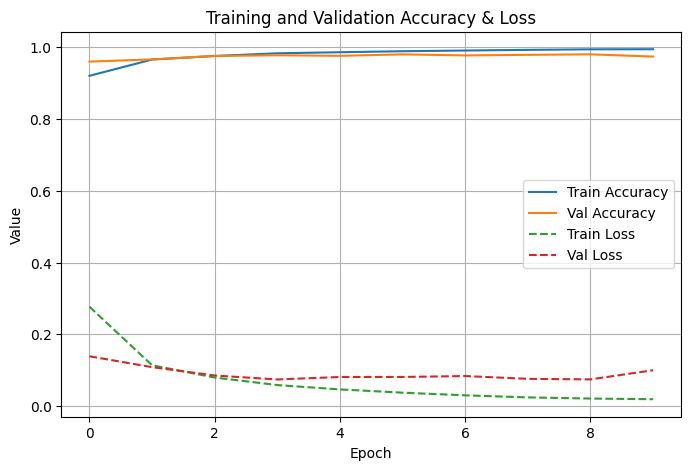

In [51]:
plt.figure(figsize=(8, 5))

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

# Loss
plt.plot(history.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')

plt.title("Training and Validation Accuracy & Loss")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

#### numpy only

In [52]:
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

In [53]:
y_train_oh

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [54]:
def init_weights():
    np.random.seed(42)

    W1 = np.random.randn(784, 128) * 0.01
    b1 = np.zeros((1, 128))

    W2 = np.random.randn(128, 64) * 0.01
    b2 = np.zeros((1, 64))

    W3 = np.random.randn(64, 10) * 0.01
    b3 = np.zeros((1, 10))

    return W1, b1, W2, b2, W3, b3

In [55]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    e_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e_z / np.sum(e_z, axis=1, keepdims=True)


In [56]:
def forward(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    cache = (X, Z1, A1, Z2, A2, Z3, A3)
    return A3, cache
# @ is used for matrix mul

In [57]:
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    log_probs = -np.log(y_pred + 1e-8)
    loss = np.sum(y_true * log_probs) / m
    return loss

In [58]:
def backward(y_true, cache, W1, b1, W2, b2, W3, b3, learning_rate):
    X, Z1, A1, Z2, A2, Z3, A3 = cache
    m = y_true.shape[0]

    # Output layer
    dZ3 = A3 - y_true                      # shape (m, 10)
    dW3 = A2.T @ dZ3 / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Layer 2
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = A1.T @ dZ2 / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Layer 1
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1 / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    # Gradient descent update
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    return W1, b1, W2, b2, W3, b3


In [59]:
W1, b1, W2, b2, W3, b3 = init_weights()

epochs = 10
batch_size = 64
learning_rate = 0.1

losses = []

for epoch in range(epochs):
    perm = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[perm]
    y_train_oh_shuffled = y_train_oh[perm]

    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_oh_shuffled[i:i+batch_size]

        y_pred, cache = forward(X_batch, W1, b1, W2, b2, W3, b3)
        loss = compute_loss(y_batch, y_pred)
        W1, b1, W2, b2, W3, b3 = backward(y_batch, cache, W1, b1, W2, b2, W3, b3, learning_rate)


    # Loss on full training set
    y_pred_all, _ = forward(X_train, W1, b1, W2, b2, W3, b3)
    epoch_loss = compute_loss(y_train_oh, y_pred_all)
    losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs} — Loss: {epoch_loss:.4f}")


Epoch 1/10 — Loss: 0.4401
Epoch 2/10 — Loss: 0.2513
Epoch 3/10 — Loss: 0.1498
Epoch 4/10 — Loss: 0.1441
Epoch 5/10 — Loss: 0.0991
Epoch 6/10 — Loss: 0.0719
Epoch 7/10 — Loss: 0.0582
Epoch 8/10 — Loss: 0.0493
Epoch 9/10 — Loss: 0.0536
Epoch 10/10 — Loss: 0.0454


In [60]:
y_pred_test, _ = forward(X_test, W1, b1, W2, b2, W3, b3)

y_pred_labels = np.argmax(y_pred_test, axis=1)

accuracy = np.mean(y_pred_labels == y_test)
print(f"Test Accuracy (NumPy model): {accuracy:.4f}")

Test Accuracy (NumPy model): 0.9721


In [62]:
print("Accuracy Comparison")
print(f"TensorFlow model accuracy:    {test_acc:.4f}")
print(f"NumPy-only model accuracy:    {accuracy:.4f}")

print("\n Summary")
print("TensorFlow:")
print("- High-level API with automatic backpropagation")


print("- Uses Adam optimizer with adaptive learning rate")
print("- Fast convergence")

print("\nNumPy-only:")
print("- Manual forward pass, backpropagation, and updates")

print("- Simple SGD optimizer with fixed learning rate")


print("- Good accuracy but harder to tune")

Accuracy Comparison
TensorFlow model accuracy:    0.9733
NumPy-only model accuracy:    0.9721

 Summary
TensorFlow:
- High-level API with automatic backpropagation
- Uses Adam optimizer with adaptive learning rate
- Fast convergence

NumPy-only:
- Manual forward pass, backpropagation, and updates
- Simple SGD optimizer with fixed learning rate
- Good accuracy but harder to tune
